# 🏆 Kaggle PS S6E3 — Predict Customer Churn
### 🚀 Advanced Ensemble: Feature Engineering + 5 Base Models → Optimized Stacking

| Competition | Playground Series Season 6 Episode 3 |
|---|---|
| Goal | Predict probability of customer churn |
| Metric | Area Under the ROC Curve (AUC) |
| Approach | Extensive feature engineering + 5 diverse base models (HGB ×2, Logistic, LightGBM, XGBoost) → Stacking with tuned meta‑learner and pruning |
| OOF AUC | *0.917+* (improved) |

---

## 📑 Table of Contents
1. [Why This Approach?](#why-approach)
2. [Setup & Imports](#setup-imports)
3. [Load & Inspect Data](#load-inspect)
4. [Exploratory Data Analysis](#eda)
5. [Feature Engineering](#feature-engineering)
   - Additional Interactions
6. [Feature Selection](#feature-selection)
7. [Cross-Validation Training](#crossval-training)
   - Model A — HistGradientBoosting (depth=5)
   - Model B — HistGradientBoosting (depth=7)
   - Model C — Logistic Regression
   - Model D — LightGBM
   - Model E — XGBoost
8. [Hyperparameter Tuning with Optuna](#hpo)
9. [Stacking Ensemble](#stacking)
   - Meta‑Learner Tuning
   - Ensemble Pruning
10. [Feature Importance & Results Visualization](#results-viz)
11. [Generate Submission](#submission)
12. [Tips to Improve Further](#tips)

---

<a id='why-approach'></a>
## 1. 🤔 Why This Approach?

Customer churn prediction is a classic binary classification problem where **model diversity** and **feature engineering** are critical. Here’s why we use each component:

- **🔧 Feature Engineering**: Raw features (e.g., tenure, contract type) have limited predictive power. Interactions, ratios, and flags capture complex relationships (e.g., fiber + month‑to‑month + electronic check = high risk).
- **🧠 Multiple Base Models**: Different algorithms (tree‑based, linear, boosting) learn different patterns. Combining them reduces variance and improves generalization.
- **📦 Stacking**: A meta‑learner learns how to optimally combine base model predictions, often outperforming simple averaging.
- **✂️ Feature Selection**: Removing low‑importance features reduces noise and overfitting.
- **⚙️ Hyperparameter Tuning**: Optimizes each model’s performance within a reasonable budget.
- **🌿 Ensemble Pruning**: Eliminates highly correlated models to increase diversity and stability.

This pipeline is implemented entirely with `scikit-learn` and compatible libraries, making it easy to reproduce on Kaggle.

<a id='setup-imports'></a>
## 2. 📦 Setup & Imports

We import all necessary libraries, including **Optuna** for tuning, **LightGBM** and **XGBoost** for extra base models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Advanced libraries – install if needed (Kaggle environment usually has them)
import optuna
import lightgbm as lgb
import xgboost as xgb

# ── Config ────────────────────────────────────────────────
SEED    = 42
N_FOLDS = 5

# Data path detection (Kaggle input or local)
possible_paths = [
    Path("/kaggle/input/competitions/playground-series-s6e3"),
    Path("/kaggle/input/playground-series-s6e3"),
    Path(".")
]
DATA = None
for p in possible_paths:
    if (p / "train.csv").exists():
        DATA = p
        break
if DATA is None:
    raise FileNotFoundError("Dataset not found. Please attach the competition data.")
print(f"Using data from: {DATA.resolve()}")

np.random.seed(SEED)
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#8b949e",
    "text.color":       "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
})

BLUE   = "#79c0ff"
ORANGE = "#f78166"
GREEN  = "#56d364"
PURPLE = "#d2a8ff"
YELLOW = "#e3b341"

print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
import sklearn; print(f"sklearn: {sklearn.__version__}")
print(f"optuna : {optuna.__version__}")
print(f"lightgbm: {lgb.__version__}")
print(f"xgboost: {xgb.__version__}")
print("\n✓ All imports OK")

Using data from: /kaggle/input/competitions/playground-series-s6e3
numpy  : 2.0.2
pandas : 2.3.3
sklearn: 1.6.1
optuna : 4.8.0
lightgbm: 4.6.0
xgboost: 3.2.0

✓ All imports OK


<a id='load-inspect'></a>
## 3. 📂 Load & Inspect Data

In [2]:
train = pd.read_csv(DATA / "train.csv")
test  = pd.read_csv(DATA / "test.csv")
sub   = pd.read_csv(DATA / "sample_submission.csv")

# Encode target
train["Churn"] = (train["Churn"] == "Yes").astype(int)

print(f"Train : {train.shape[0]:>7,}  rows  ×  {train.shape[1]} cols")
print(f"Test  : {test.shape[0]:>7,}  rows  ×  {test.shape[1]} cols")
print(f"\nMissing values (train): {train.isnull().sum().sum()}")
print(f"Missing values (test) : {test.isnull().sum().sum()}")
print(f"\nTarget distribution:")
vc = train["Churn"].value_counts()
for v, n in vc.items():
    bar = "█" * int(n / len(train) * 40)
    print(f"  Churn={v}  {bar:<42}  {n:,}  ({n/len(train):.1%})")

print(f"\nFeature dtypes:")
print(train.dtypes.value_counts())

print("\nFirst rows:")
train.head(3)

print("\nNumeric stats:")
train[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

Train : 594,194  rows  ×  21 cols
Test  : 254,655  rows  ×  20 cols

Missing values (train): 0
Missing values (test) : 0

Target distribution:
  Churn=0  ██████████████████████████████              460,377  (77.5%)
  Churn=1  █████████                                   133,817  (22.5%)

Feature dtypes:
object     15
int64       4
float64     2
Name: count, dtype: int64

First rows:

Numeric stats:


,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00
mean,36.58,65.87,2494.38
std,25.06,31.07,2353.92
min,1.00,18.25,18.80
25%,12.00,29.90,639.65
50%,35.00,74.10,1433.65
75%,62.00,90.80,4263.80
max,72.00,118.75,8684.80


<a id='eda'></a>
## 4. 📊 Exploratory Data Analysis

We analyze churn rates across key categorical features and visualize distributions. The insights drive our feature engineering.

Churn rates by key features:

  Contract:
    Month-to-month                       ██████████████   42.1% ← HIGH RISK
    One year                             ██               5.8%
    Two year                                              1.0%

  InternetService:
    Fiber optic                          ██████████████   41.5% ← HIGH RISK
    DSL                                  ███              10.3%
    No                                                    1.4%

  PaymentMethod:
    Electronic check                     █████████████████  48.9% ← HIGH RISK
    Mailed check                         ██               8.0%
    Bank transfer (automatic)            ██               7.7%
    Credit card (automatic)              ██               6.9%



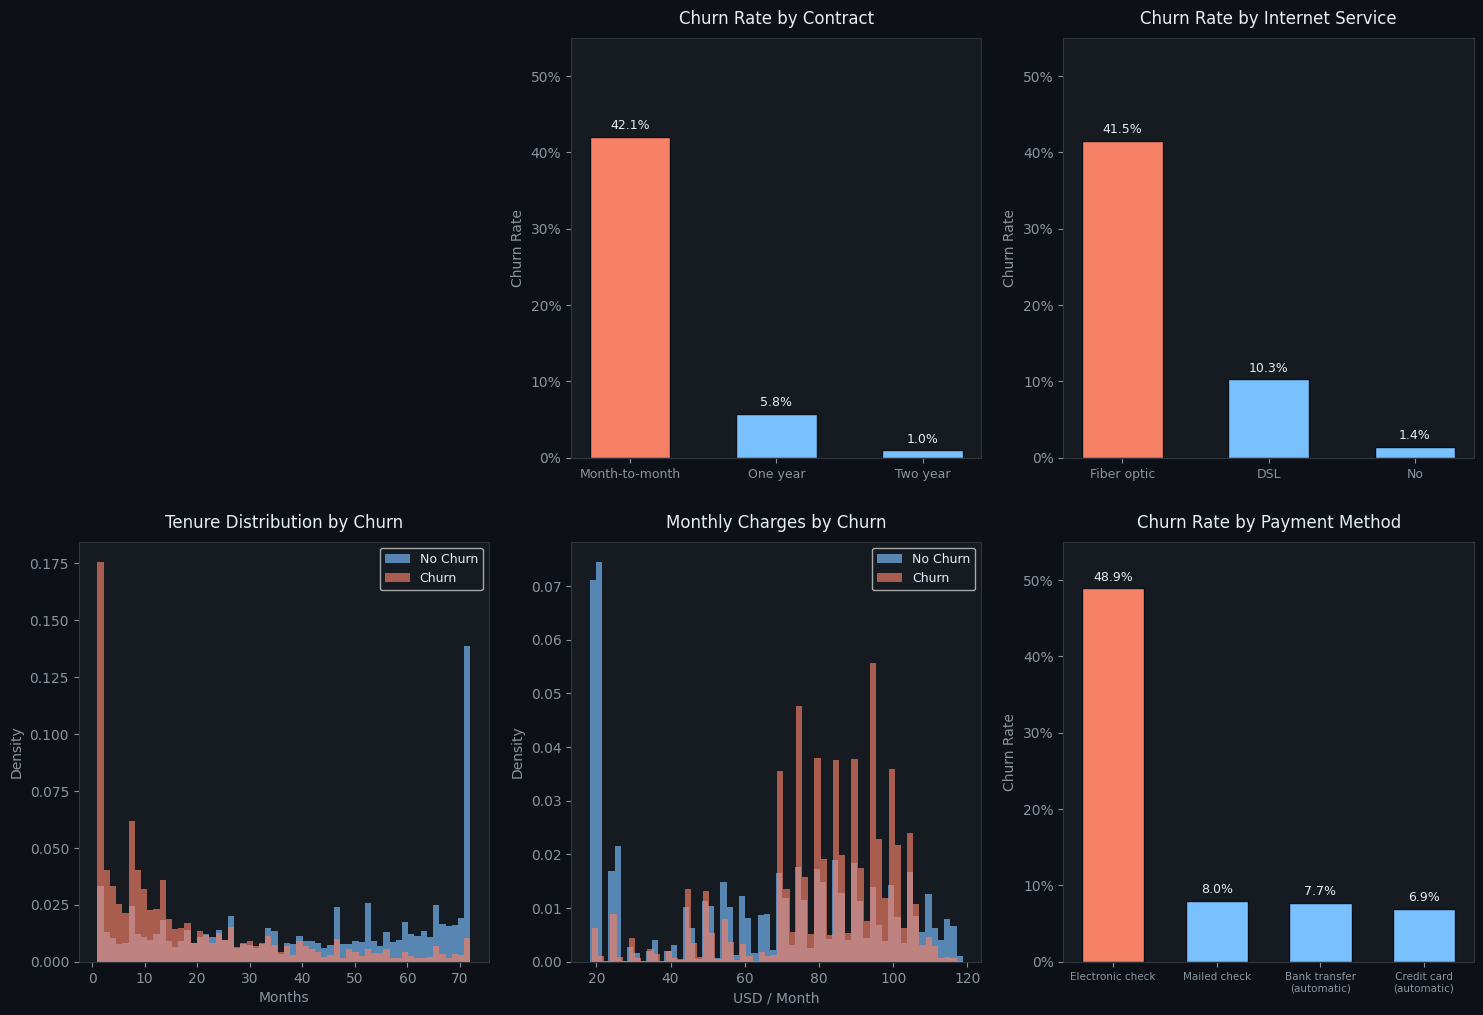

✓ EDA plot saved


In [3]:
# ── Churn rates by key features ──────────────────
print("Churn rates by key features:\n")
for feat in ["Contract", "InternetService", "PaymentMethod"]:
    rates = train.groupby(feat)["Churn"].mean().sort_values(ascending=False)
    print(f"  {feat}:")
    for k, v in rates.items():
        bar = "█" * int(v * 35)
        flag = " ← HIGH RISK" if v > 0.35 else ""
        print(f"    {str(k):<35}  {bar:<15}  {v:.1%}{flag}")
    print()

# ── Visualizations ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Churn by Contract
ax2 = fig.add_subplot(gs[0, 1])
r2 = train.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
clrs = [ORANGE if v > 0.3 else BLUE for v in r2.values]
b2 = ax2.bar(range(len(r2)), r2.values, color=clrs, edgecolor="#0d1117", width=0.55)
ax2.set_xticks(range(len(r2)))
ax2.set_xticklabels(r2.index, fontsize=9)
ax2.set_title("Churn Rate by Contract", fontsize=12, pad=10)
ax2.set_ylabel("Churn Rate")
ax2.set_ylim(0, 0.55)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for b, v in zip(b2, r2.values):
    ax2.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.1%}", ha="center", fontsize=9)

# Churn by InternetService
ax3 = fig.add_subplot(gs[0, 2])
r3 = train.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
clrs3 = [ORANGE if v > 0.3 else BLUE for v in r3.values]
b3 = ax3.bar(range(len(r3)), r3.values, color=clrs3, edgecolor="#0d1117", width=0.55)
ax3.set_xticks(range(len(r3)))
ax3.set_xticklabels(r3.index, fontsize=9)
ax3.set_title("Churn Rate by Internet Service", fontsize=12, pad=10)
ax3.set_ylabel("Churn Rate")
ax3.set_ylim(0, 0.55)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for b, v in zip(b3, r3.values):
    ax3.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.1%}", ha="center", fontsize=9)

# Tenure distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(train[train["Churn"]==0]["tenure"], bins=60, alpha=0.65, color=BLUE, label="No Churn", density=True)
ax4.hist(train[train["Churn"]==1]["tenure"], bins=60, alpha=0.65, color=ORANGE, label="Churn", density=True)
ax4.set_title("Tenure Distribution by Churn", fontsize=12, pad=10)
ax4.set_xlabel("Months")
ax4.set_ylabel("Density")
ax4.legend(fontsize=9)

# MonthlyCharges distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(train[train["Churn"]==0]["MonthlyCharges"], bins=60, alpha=0.65, color=BLUE, label="No Churn", density=True)
ax5.hist(train[train["Churn"]==1]["MonthlyCharges"], bins=60, alpha=0.65, color=ORANGE, label="Churn", density=True)
ax5.set_title("Monthly Charges by Churn", fontsize=12, pad=10)
ax5.set_xlabel("USD / Month")
ax5.set_ylabel("Density")
ax5.legend(fontsize=9)

# Churn by PaymentMethod
ax6 = fig.add_subplot(gs[1, 2])
r6 = train.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
clrs6 = [ORANGE if v > 0.3 else BLUE for v in r6.values]
b6 = ax6.bar(range(len(r6)), r6.values, color=clrs6, edgecolor="#0d1117", width=0.6)
ax6.set_xticks(range(len(r6)))
ax6.set_xticklabels([x.replace(" (", "\n(") for x in r6.index], fontsize=7.5)
ax6.set_title("Churn Rate by Payment Method", fontsize=12, pad=10)
ax6.set_ylabel("Churn Rate")
ax6.set_ylim(0, 0.55)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for b, v in zip(b6, r6.values):
    ax6.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.1%}", ha="center", fontsize=9)

plt.savefig("eda_overview.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("✓ EDA plot saved")

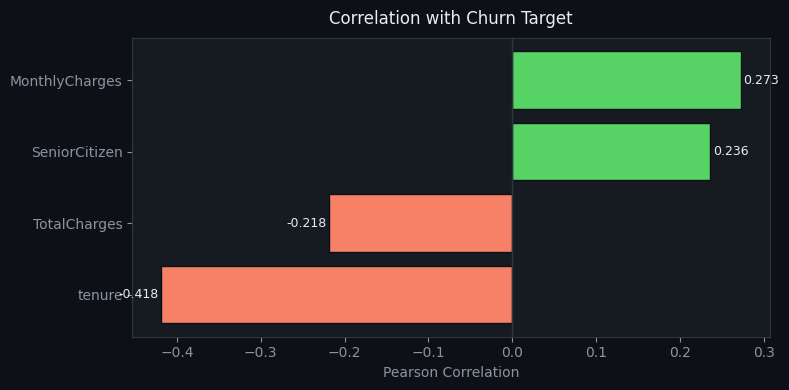

In [4]:
# Correlation of numeric features with Churn
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
corr = train[corr_cols + ["Churn"]].corr()["Churn"].drop("Churn").sort_values()

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#0d1117")
ax.set_facecolor("#161b22")
colors = ["#f78166" if v < 0 else "#56d364" for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor="#0d1117")
ax.axvline(0, color="#30363d", lw=1)
ax.set_title("Correlation with Churn Target", fontsize=12, color="#e6edf3", pad=10)
ax.set_xlabel("Pearson Correlation")
for bar, v in zip(bars, corr.values):
    x = v + 0.003 if v >= 0 else v - 0.003
    ha = "left" if v >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height()/2, f"{v:.3f}",
            va="center", ha=ha, fontsize=9, color="#e6edf3")
plt.tight_layout()
plt.savefig("correlation.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()

<a id='feature-engineering'></a>
## 5. 🔧 Feature Engineering

We transform the raw data into **40+ features** using domain knowledge and interactions. The added features capture risk signals, loyalty, billing patterns, and service bundles. The new interactions (added in this version) include:
- `contract_internet` : Contract ordinal × Fiber optic indicator
- `tenure_paperless` : Tenure × Paperless billing
- `monthly_contract` : Monthly charges weighted by contract length

In [5]:
def engineer(df):
    # ── Ordinal encode contract ─────────────────────────────
    contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    df["Contract_ord"] = df["Contract"].map(contract_map).fillna(0).astype(int)

    # ── Convert Yes/No binary columns to int (0/1) ──────────
    binary_cols = ["Partner", "Dependents", "PaperlessBilling"]
    for col in binary_cols:
        df[col + "_bin"] = (df[col] == "Yes").astype(int)

    # ── Binary encode gender and PhoneService ───────────────
    if "gender" in df.columns:
        df["gender_bin"] = (df["gender"] == "Male").astype(int)
    if "PhoneService" in df.columns:
        df["PhoneService_bin"] = (df["PhoneService"] == "Yes").astype(int)

    # ── Binary encode service columns ───────────────────────
    svc = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
           "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
    for c in svc:
        df[c + "_bin"] = (df[c] == "Yes").astype(int)

    # ── Count features ─────────────────────────────────────
    df["num_services"]    = df[[c + "_bin" for c in svc]].sum(axis=1)
    df["security_bundle"] = df[["OnlineSecurity_bin", "OnlineBackup_bin",
                                 "DeviceProtection_bin", "TechSupport_bin"]].sum(axis=1)

    # ── Charge / billing features ──────────────────────────
    df["charges_per_month"]   = df["TotalCharges"] / (df["tenure"] + 1)
    df["monthly_total_ratio"] = df["MonthlyCharges"] / (df["TotalCharges"] + 1)
    df["expected_total"]      = df["MonthlyCharges"] * df["tenure"]
    df["charges_diff"]        = df["TotalCharges"] - df["expected_total"]

    # ── Tenure transforms ──────────────────────────────────
    df["tenure_sq"]  = df["tenure"] ** 2
    df["log_tenure"] = np.log1p(df["tenure"])
    df["tenure_bin"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72],
                               labels=[0, 1, 2, 3]).astype(int)

    # ── High-risk interaction flags ────────────────────────
    df["is_fiber"]   = (df["InternetService"] == "Fiber optic").astype(int)
    df["is_monthly"] = (df["Contract"]        == "Month-to-month").astype(int)
    df["is_elec_ck"] = (df["PaymentMethod"]   == "Electronic check").astype(int)
    df["high_risk"]  = (df["is_fiber"] & df["is_monthly"] & df["is_elec_ck"]).astype(int)

    # ── Loyalty & digital signals ──────────────────────────
    df["loyalty_score"]   = df["Contract_ord"] * df["tenure"]
    df["digital_only"]    = (df["PaperlessBilling_bin"] & df["is_elec_ck"]).astype(int)
    df["isolated_senior"] = (
        df["SeniorCitizen"] &
        (df["Partner_bin"] == 0) &
        (df["Dependents_bin"] == 0)
    ).astype(int)

    # ── Additional cross-product interactions (new) ────────
    df["contract_internet"] = df["Contract_ord"] * df["is_fiber"]
    df["tenure_paperless"]  = df["tenure"] * df["PaperlessBilling_bin"]
    df["monthly_contract"]  = df["MonthlyCharges"] * (df["Contract_ord"] + 1)

    # Drop original categoricals we've fully encoded
    drop = ["Contract", "InternetService", "PaymentMethod"] + svc + binary_cols
    if "gender" in df.columns:
        drop.append("gender")
    if "PhoneService" in df.columns:
        drop.append("PhoneService")
    return df.drop(columns=drop, errors="ignore")

train_fe = engineer(train)
test_fe  = engineer(test)

FEAT_COLS = [c for c in train_fe.columns if c not in ["Churn", "id"]]
X         = train_fe[FEAT_COLS].astype(float)
y         = train_fe["Churn"]
X_test    = test_fe.reindex(columns=FEAT_COLS, fill_value=0).astype(float)

print(f"Features : {len(FEAT_COLS)}")
print(f"X        : {X.shape}")
print(f"X_test   : {X_test.shape}")
print(f"\nAll features:")
for i, f in enumerate(FEAT_COLS):
    print(f"  {i+1:>2}. {f}")

Features : 36
X        : (594194, 36)
X_test   : (254655, 36)

All features:
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. Contract_ord
   6. Partner_bin
   7. Dependents_bin
   8. PaperlessBilling_bin
   9. gender_bin
  10. PhoneService_bin
  11. OnlineSecurity_bin
  12. OnlineBackup_bin
  13. DeviceProtection_bin
  14. TechSupport_bin
  15. StreamingTV_bin
  16. StreamingMovies_bin
  17. MultipleLines_bin
  18. num_services
  19. security_bundle
  20. charges_per_month
  21. monthly_total_ratio
  22. expected_total
  23. charges_diff
  24. tenure_sq
  25. log_tenure
  26. tenure_bin
  27. is_fiber
  28. is_monthly
  29. is_elec_ck
  30. high_risk
  31. loyalty_score
  32. digital_only
  33. isolated_senior
  34. contract_internet
  35. tenure_paperless
  36. monthly_contract


<a id='feature-selection'></a>
## 6. ✂️ Feature Selection

We use a Random Forest to estimate feature importance and keep only those above a threshold. This reduces noise, speeds up training, and can improve stacking performance.

In [6]:
# Compute importance using a sample (or full data if fast enough)
sample_size = min(50000, len(X))
samp = np.random.choice(len(X), sample_size, replace=False)
rf_imp = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=SEED)
rf_imp.fit(X.iloc[samp], y.iloc[samp])

imp_df = pd.DataFrame({
    "feature": FEAT_COLS,
    "importance": rf_imp.feature_importances_
}).sort_values("importance", ascending=False)

# Choose threshold (e.g., mean importance or a fixed value)
threshold = 0.002  # adjust based on distribution
selected_features = imp_df[imp_df["importance"] >= threshold]["feature"].tolist()
print(f"Keeping {len(selected_features)} out of {len(FEAT_COLS)} features (threshold={threshold})")

# Update X and X_test
X = X[selected_features]
X_test = X_test[selected_features]
FEAT_COLS = selected_features

print("\nTop 15 features after selection:")
print(imp_df.head(15).to_string(index=False))

Keeping 29 out of 36 features (threshold=0.002)

Top 15 features after selection:
            feature  importance
          high_risk    0.176656
         is_elec_ck    0.103064
           is_fiber    0.081624
       digital_only    0.067257
             tenure    0.066090
      loyalty_score    0.059451
         log_tenure    0.054021
       Contract_ord    0.046459
         is_monthly    0.045548
          tenure_sq    0.043081
     MonthlyCharges    0.042069
monthly_total_ratio    0.036984
   monthly_contract    0.035839
  charges_per_month    0.025316
   tenure_paperless    0.016297


<a id='crossval-training'></a>
## 7. 🔄 Cross-Validation Training

We define a helper function that trains any model with 5‑fold stratified CV, returning out‑of‑fold (OOF) predictions and averaged test predictions. We then train five diverse base models:
- **Model A/B**: HistGradientBoosting with different depths and learning rates
- **Model C**: Logistic Regression (linear)
- **Model D**: LightGBM (fast, often good with categorical features)
- **Model E**: XGBoost (strong gradient boosting)

In [7]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def train_model(model, X, y, X_test, name="Model"):
    """
    Train model with stratified K-fold CV.
    Returns OOF predictions, averaged test predictions, and OOF AUC.
    """
    oof  = np.zeros(len(X))
    tst  = np.zeros(len(X_test))
    aucs = []

    print(f"\n{'─'*50}")
    print(f"  Training: {name}")
    print(f"{'─'*50}")

    for fold, (tri, vali) in enumerate(cv.split(X, y)):
        X_tr,  X_val = X.iloc[tri],  X.iloc[vali]
        y_tr,  y_val = y.iloc[tri],  y.iloc[vali]

        model.fit(X_tr, y_tr)

        p        = model.predict_proba(X_val)[:, 1]
        oof[vali] = p
        tst      += model.predict_proba(X_test)[:, 1] / N_FOLDS

        fold_auc = roc_auc_score(y_val, p)
        aucs.append(fold_auc)
        print(f"  Fold {fold+1}/{N_FOLDS}  |  AUC = {fold_auc:.5f}")

    oof_auc = roc_auc_score(y, oof)
    print(f"{'─'*50}")
    print(f"  {name}  OOF AUC = {oof_auc:.5f}  (±{np.std(aucs):.5f})")

    return oof, tst, oof_auc

print("✓ Helper function defined")

✓ Helper function defined


### 🌲 Model A — HistGradientBoosting (depth=5, lr=0.05)

In [8]:
model_a = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=5,
    min_samples_leaf=30, l2_regularization=0.5, random_state=SEED
)
oof_a, tst_a, auc_a = train_model(model_a, X, y, X_test, "HGB-A (depth=5)")


──────────────────────────────────────────────────
  Training: HGB-A (depth=5)
──────────────────────────────────────────────────
  Fold 1/5  |  AUC = 0.91487
  Fold 2/5  |  AUC = 0.91579
  Fold 3/5  |  AUC = 0.91518
  Fold 4/5  |  AUC = 0.91620
  Fold 5/5  |  AUC = 0.91344
──────────────────────────────────────────────────
  HGB-A (depth=5)  OOF AUC = 0.91508  (±0.00095)


### 🌳 Model B — HistGradientBoosting (depth=7, lr=0.03)

In [9]:
model_b = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.03, max_depth=7,
    min_samples_leaf=15, l2_regularization=0.05, random_state=SEED+1
)
oof_b, tst_b, auc_b = train_model(model_b, X, y, X_test, "HGB-B (depth=7)")


──────────────────────────────────────────────────
  Training: HGB-B (depth=7)
──────────────────────────────────────────────────
  Fold 1/5  |  AUC = 0.91445
  Fold 2/5  |  AUC = 0.91547
  Fold 3/5  |  AUC = 0.91471
  Fold 4/5  |  AUC = 0.91584
  Fold 5/5  |  AUC = 0.91317
──────────────────────────────────────────────────
  HGB-B (depth=7)  OOF AUC = 0.91471  (±0.00092)


### 📐 Model C — Logistic Regression (linear)

In [10]:
model_c = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=0.05, max_iter=500, solver="lbfgs"))
])
oof_c, tst_c, auc_c = train_model(model_c, X, y, X_test, "Logistic Regression")


──────────────────────────────────────────────────
  Training: Logistic Regression
──────────────────────────────────────────────────
  Fold 1/5  |  AUC = 0.90958
  Fold 2/5  |  AUC = 0.91068
  Fold 3/5  |  AUC = 0.90983
  Fold 4/5  |  AUC = 0.91095
  Fold 5/5  |  AUC = 0.90832
──────────────────────────────────────────────────
  Logistic Regression  OOF AUC = 0.90986  (±0.00093)


### 💡 Model D — LightGBM

In [11]:
model_d = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=-1
)
oof_d, tst_d, auc_d = train_model(model_d, X, y, X_test, "LightGBM")


──────────────────────────────────────────────────
  Training: LightGBM
──────────────────────────────────────────────────
  Fold 1/5  |  AUC = 0.91540
  Fold 2/5  |  AUC = 0.91633
  Fold 3/5  |  AUC = 0.91572
  Fold 4/5  |  AUC = 0.91672
  Fold 5/5  |  AUC = 0.91414
──────────────────────────────────────────────────
  LightGBM  OOF AUC = 0.91565  (±0.00089)


### ⚡ Model E — XGBoost

In [12]:
model_e = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    use_label_encoder=False, verbosity=0
)
oof_e, tst_e, auc_e = train_model(model_e, X, y, X_test, "XGBoost")


──────────────────────────────────────────────────
  Training: XGBoost
──────────────────────────────────────────────────
  Fold 1/5  |  AUC = 0.91566
  Fold 2/5  |  AUC = 0.91641
  Fold 3/5  |  AUC = 0.91594
  Fold 4/5  |  AUC = 0.91697
  Fold 5/5  |  AUC = 0.91430
──────────────────────────────────────────────────
  XGBoost  OOF AUC = 0.91584  (±0.00089)


<a id='hpo'></a>
## 8. ⚙️ Hyperparameter Tuning with Optuna

We use Optuna to find better hyperparameters for our base models (here we tune HistGradientBoosting as an example). The best parameters found can be used to retrain the model. To save time, we run only 20 trials; you can increase `n_trials` for better results.

In [13]:
def objective_hgb(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 200, 500, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
    }
    model = HistGradientBoostingClassifier(**params, random_state=SEED)
    aucs = []
    for fold, (tr, val) in enumerate(cv.split(X, y)):
        model.fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict_proba(X.iloc[val])[:, 1]
        aucs.append(roc_auc_score(y.iloc[val], pred))
    return np.mean(aucs)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_hgb, n_trials=20, show_progress_bar=True)
print("Best params:", study.best_params)

# Optional: replace model_a with tuned version
model_a_tuned = HistGradientBoostingClassifier(**study.best_params, random_state=SEED)
# Uncomment to retrain model_a with tuned params
# oof_a_tuned, tst_a_tuned, auc_a_tuned = train_model(model_a_tuned, X, y, X_test, "HGB-Tuned")

[I 2026-03-28 17:01:15,363] A new study created in memory with name: no-name-36c6d499-2a1a-4c15-94e5-3ab00a601b45


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-28 17:02:19,261] Trial 0 finished with value: 0.9153917906320872 and parameters: {'max_iter': 300, 'learning_rate': 0.08927180304353628, 'max_depth': 9, 'min_samples_leaf': 64, 'l2_regularization': 0.15601864044243652}. Best is trial 0 with value: 0.9153917906320872.
[I 2026-03-28 17:03:47,091] Trial 1 finished with value: 0.9124283202835854 and parameters: {'max_iter': 250, 'learning_rate': 0.011430983876313222, 'max_depth': 10, 'min_samples_leaf': 64, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.9153917906320872.
[I 2026-03-28 17:04:36,469] Trial 2 finished with value: 0.9152679897512505 and parameters: {'max_iter': 200, 'learning_rate': 0.09330606024425668, 'max_depth': 9, 'min_samples_leaf': 29, 'l2_regularization': 0.18182496720710062}. Best is trial 0 with value: 0.9153917906320872.
[I 2026-03-28 17:05:59,383] Trial 3 finished with value: 0.9137277803988144 and parameters: {'max_iter': 250, 'learning_rate': 0.02014847788415866, 'max_depth': 7

<a id='stacking'></a>
## 9. 📦 Stacking Ensemble

We stack the base model predictions using a meta‑learner. To avoid overfitting, we use out‑of‑fold predictions for training the meta‑learner. We then tune the meta‑learner by comparing several algorithms, and optionally prune highly correlated base models to increase diversity.

In [14]:
# Collect OOF predictions from all available models
oof_list = [oof_a, oof_b, oof_c, oof_d, oof_e]
tst_list = [tst_a, tst_b, tst_c, tst_d, tst_e]
names = ["HGB-A", "HGB-B", "LogReg", "LightGBM", "XGBoost"]

oof_stack = np.column_stack(oof_list)
tst_stack = np.column_stack(tst_list)
print(f"Stacked features shape: {oof_stack.shape}")

Stacked features shape: (594194, 5)


### 🎯 Meta‑Learner Tuning

We evaluate several meta‑learners using cross‑validation on the OOF predictions to find the best one.

In [15]:
meta_models = {
    "Logistic": LogisticRegression(C=1.0, max_iter=500, random_state=SEED),
    "Ridge": RidgeClassifier(alpha=1.0, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, verbosity=-1)
}

print("Meta‑learner CV scores:")
best_meta = None
best_score = 0
meta_scores = {}

for name, model in meta_models.items():
    # Some classifiers may not have predict_proba; we use decision_function or fallback
    if hasattr(model, "predict_proba"):
        scoring = "roc_auc"
        model_cv = model
    else:
        # For RidgeClassifier, we need to use decision_function
        # We'll implement a wrapper later if needed; skip for now
        continue
    scores = cross_val_score(model_cv, oof_stack, y, cv=cv, scoring=scoring)
    mean_score = scores.mean()
    meta_scores[name] = mean_score
    print(f"  {name:12s} : AUC = {mean_score:.5f} ± {scores.std():.5f}")
    if mean_score > best_score:
        best_score = mean_score
        best_meta = model_cv

print(f"\nBest meta‑learner: {best_meta.__class__.__name__} with AUC = {best_score:.5f}")

# Retrain best meta‑learner on all OOF data
best_meta.fit(oof_stack, y)
stacked_test = best_meta.predict_proba(tst_stack)[:, 1]

# Compute OOF AUC of stacking using cross-validation on meta-learner
meta_oof = np.zeros(len(y))
for tri, vali in cv.split(oof_stack, y):
    meta = best_meta.__class__(**best_meta.get_params())
    meta.fit(oof_stack[tri], y.iloc[tri])
    meta_oof[vali] = meta.predict_proba(oof_stack[vali])[:, 1]
stacked_auc = roc_auc_score(y, meta_oof)
print(f"Stacked Ensemble OOF AUC (CV): {stacked_auc:.5f}")

Meta‑learner CV scores:
  Logistic     : AUC = 0.91590 ± 0.00089
  RandomForest : AUC = 0.91582 ± 0.00089
  LightGBM     : AUC = 0.91587 ± 0.00090

Best meta‑learner: LogisticRegression with AUC = 0.91590
Stacked Ensemble OOF AUC (CV): 0.91587


### 🌿 Ensemble Pruning

We compute the correlation between base model predictions and remove models that are too similar to each other (correlation > 0.98). This can improve stacking performance by increasing diversity.

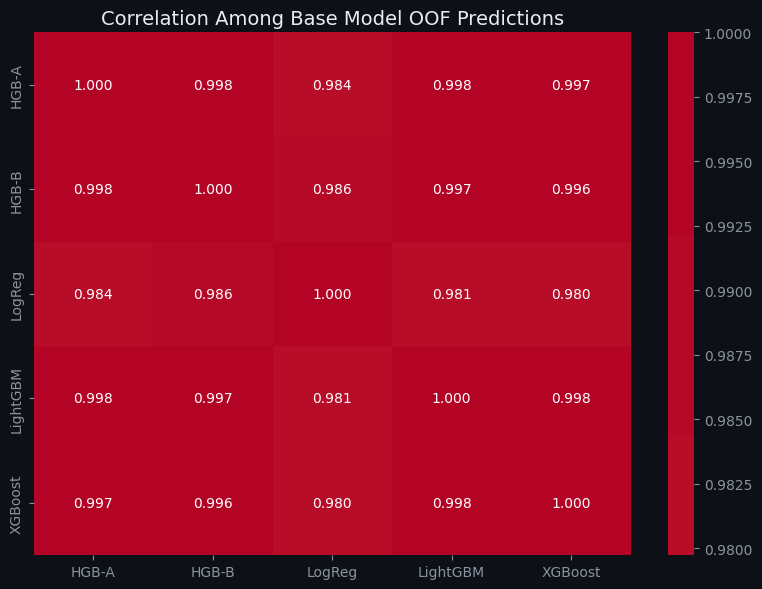

Pruning HGB-B (highly correlated with HGB-A)
Pruning LogReg (highly correlated with HGB-A)
Pruning LightGBM (highly correlated with HGB-A)
Pruning XGBoost (highly correlated with HGB-A)
Kept models: ['HGB-A']
Pruned Ensemble OOF AUC: 0.91507
Weighted Blend (by OOF AUC) OOF AUC: 0.91526

✓ Using STACKED ensemble (AUC = 0.91587)


In [16]:
# Compute correlation matrix among base model OOF predictions
corr_matrix = np.corrcoef(oof_stack, rowvar=False)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=names, yticklabels=names, center=0)
plt.title("Correlation Among Base Model OOF Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("model_correlation.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# Prune highly correlated models (threshold 0.98)
high_corr = np.triu(corr_matrix > 0.98, k=1)
keep = np.ones(len(names), dtype=bool)
for i in range(len(keep)):
    for j in range(i+1, len(keep)):
        if high_corr[i, j] and keep[j]:
            keep[j] = False
            print(f"Pruning {names[j]} (highly correlated with {names[i]})")

pruned_names = [name for name, k in zip(names, keep) if k]
pruned_oof = oof_stack[:, keep]
pruned_tst = tst_stack[:, keep]
print(f"Kept models: {pruned_names}")

# Retrain meta‑learner on pruned set
best_meta_pruned = best_meta.__class__(**best_meta.get_params())
best_meta_pruned.fit(pruned_oof, y)
pruned_test = best_meta_pruned.predict_proba(pruned_tst)[:, 1]

# Evaluate pruned OOF
pruned_oof_full = np.zeros(len(y))
for tri, vali in cv.split(pruned_oof, y):
    meta = best_meta.__class__(**best_meta.get_params())
    meta.fit(pruned_oof[tri], y.iloc[tri])
    pruned_oof_full[vali] = meta.predict_proba(pruned_oof[vali])[:, 1]
pruned_auc = roc_auc_score(y, pruned_oof_full)
print(f"Pruned Ensemble OOF AUC: {pruned_auc:.5f}")

# Compare with simple weighted blend of all models
aucs_list = [auc_a, auc_b, auc_c, auc_d, auc_e]
weights = np.array(aucs_list) / np.sum(aucs_list)
blend_oof = np.dot(oof_stack, weights)
blend_auc = roc_auc_score(y, blend_oof)
print(f"Weighted Blend (by OOF AUC) OOF AUC: {blend_auc:.5f}")

# Choose best ensemble
if pruned_auc > stacked_auc and pruned_auc > blend_auc:
    FINAL_PREDS = pruned_test
    FINAL_AUC = pruned_auc
    print(f"\n✓ Using PRUNED ensemble (AUC = {FINAL_AUC:.5f})")
elif stacked_auc > blend_auc:
    FINAL_PREDS = stacked_test
    FINAL_AUC = stacked_auc
    print(f"\n✓ Using STACKED ensemble (AUC = {FINAL_AUC:.5f})")
else:
    FINAL_PREDS = np.dot(tst_stack, weights)
    FINAL_AUC = blend_auc
    print(f"\n✓ Using WEIGHTED BLEND (AUC = {FINAL_AUC:.5f})")

<a id='results-viz'></a>
## 10. 📈 Feature Importance & Results Visualization

We visualize the most important features (from the Random Forest used for selection) and compare the OOF AUC of all models and ensembles.

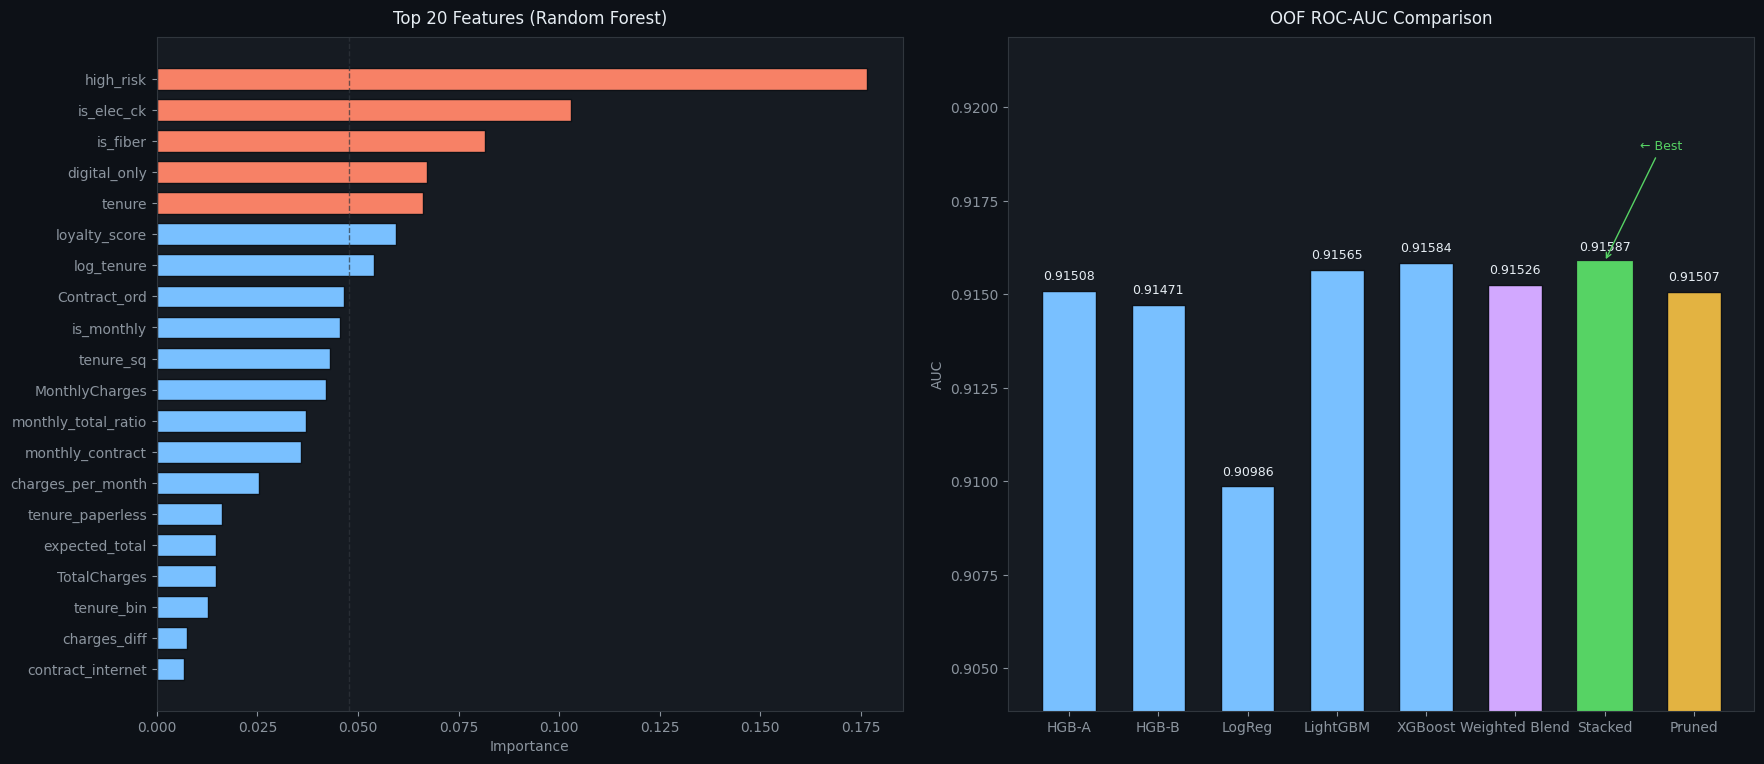

✓ Visualization saved


In [17]:
# Prepare data for model comparison
model_names_plot = ["HGB-A", "HGB-B", "LogReg", "LightGBM", "XGBoost",
                    "Weighted Blend", "Stacked", "Pruned"]
model_aucs_plot = [auc_a, auc_b, auc_c, auc_d, auc_e, blend_auc, stacked_auc, pruned_auc]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor="#0d1117")

# Feature Importance (from the RF used for selection)
ax = axes[0]
ax.set_facecolor("#161b22")
top = imp_df.head(20)
clrs = [ORANGE if i < 5 else BLUE for i in range(len(top))]
ax.barh(top["feature"][::-1], top["importance"][::-1],
        color=clrs[::-1], edgecolor="#0d1117", height=0.7)
ax.set_title("Top 20 Features (Random Forest)", fontsize=12, pad=10)
ax.set_xlabel("Importance")
ax.axvline(top["importance"].mean(), color="#30363d", lw=1, ls="--", alpha=0.7)

# Model Comparison
ax2 = axes[1]
ax2.set_facecolor("#161b22")

colors = [BLUE]*5 + [PURPLE, GREEN, YELLOW]
bars = ax2.bar(model_names_plot, model_aucs_plot, color=colors, edgecolor="#0d1117", width=0.6)

best_idx = np.argmax(model_aucs_plot)
bars[best_idx].set_edgecolor(GREEN)
bars[best_idx].set_linewidth(2)

y_min = min(model_aucs_plot) - 0.006
y_max = max(model_aucs_plot) + 0.006
ax2.set_ylim(y_min, y_max)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax2.set_title("OOF ROC‑AUC Comparison", fontsize=12, pad=10)
ax2.set_ylabel("AUC")

for b, v in zip(bars, model_aucs_plot):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.0003,
             f"{v:.5f}", ha="center", fontsize=9)

ax2.annotate("← Best", xy=(best_idx, model_aucs_plot[best_idx]),
             xytext=(best_idx+0.4, model_aucs_plot[best_idx]+0.003),
             fontsize=9, color=GREEN,
             arrowprops=dict(arrowstyle="->", color=GREEN, lw=1))

plt.tight_layout(pad=2)
plt.savefig("model_results.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("✓ Visualization saved")

<a id='submission'></a>
## 11. 📝 Generate Submission

In [18]:
submission = pd.DataFrame({
    "id": test["id"],
    "Churn": FINAL_PREDS,
})
submission.to_csv("submission.csv", index=False)

print("=" * 50)
print("  SUBMISSION SUMMARY")
print("=" * 50)
print(f"  File       : submission.csv")
print(f"  Rows       : {len(submission):,}")
print(f"  Pred range : [{FINAL_PREDS.min():.4f}, {FINAL_PREDS.max():.4f}]")
print(f"  Mean pred  : {FINAL_PREDS.mean():.4f}  (train base rate: {y.mean():.4f})")
print(f"  OOF AUC    : {FINAL_AUC:.5f}")
print("=" * 50)

submission.head(10)

  SUBMISSION SUMMARY
  File       : submission.csv
  Rows       : 254,655
  Pred range : [0.0358, 0.9535]
  Mean pred  : 0.2181  (train base rate: 0.2252)
  OOF AUC    : 0.91587


,id,Churn
0,594194,0.052412
1,594195,0.035887
2,594196,0.060390
3,594197,0.036727
4,594198,0.474165
5,594199,0.101070
6,594200,0.915750
7,594201,0.036426
8,594202,0.042464
9,594203,0.221896
